In [44]:
# PREPARAÇÂO E INTEGRAÇÃO DE DADOS

import pandas
import numpy as np
import matplotlib.pyplot as plt

In [45]:
# Carregando os arquivos
crimes = pandas.read_csv(r"C:\Users\Aluno.SantaLuzia\Documents\Elaine\uc2\bases\03.BaseDPEvolucaoMensalCisp.csv", sep=';', encoding='iso-8859-1')
delegacias = pandas.read_csv(r"C:\Users\Aluno.SantaLuzia\Documents\Elaine\uc2\bases\08.DP.csv")

# Merge das bases
crimesJoinDelegacias = pandas.merge(crimes, delegacias, right_on='codDP', left_on='cisp')
crimes_delegacias = crimesJoinDelegacias[['nome', 'mes', 'ano', 'mes_ano', 'apreensao_drogas', 'trafico_drogas', 'regiao']]

In [46]:
# Tratamento de valores nulos

for coluna in ["apreensao_drogas", "trafico_drogas"]:
    crimes_delegacias[coluna] = crimes_delegacias[coluna].fillna(crimes_delegacias[coluna].median())

In [49]:
# DIAGNÓSTICO ESTATÍSTICO

def estatisticas(df, coluna):
    
    # Medidas de Tendência Central
    media = df[coluna].mean()
    mediana = df[coluna].median()
    moda = df[coluna].mode().iloc[0]
    
    # Dispersão
    variancia = df[coluna].var()
    desvio = df[coluna].std()
    cv = (desvio / media) * 100 if media != 0 else np.nan
    
    # Posição e Limites
    minimo = df[coluna].min()
    maximo = df[coluna].max()
    amplitude = maximo - minimo
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5*iqr
    ls = q3 + 1.5*iqr

    # Formato da distribuição
    assimetria = df[coluna].skew()
    curtose = df[coluna].kurt()
    delta = media - mediana
    
    estatisticas = {
        'coluna' : coluna,
        'media' : media,
        'mediana' : mediana,
        'moda' : moda,
        'desvio' : desvio,
        'variancia' : variancia,
        'cv' : cv,
        'minimo' : minimo,
        'maximo' : maximo,
        'amplitude' : amplitude,
        'q1' : q1,
        'q2' : q2,
        'q3' : q3,
        'iqr' : iqr,
        'limite superior' : ls,
        'limite inferior' : li,
        'assimetria' : assimetria,
        'curtose' : curtose,
        'delta' : delta
    }

    return estatisticas

In [50]:
# impressão das estatisticas

def imprimir_estatisticas(e):
    
    print(f"\nDIAGNÓSTICO ESTATÍSTICO DE {e['coluna'].upper()}\n")
    print(f"Média: {e['media']:.2f}")
    print(f"Mediana: {e['mediana']:.2f}")
    print(f"Moda: {e['moda']}")
    print(f"Desvio padrão: {e['desvio']:.2f}")
    print(f"Variância: {e['variancia']:.2f}")
    print(f"CV: {e['cv']:.2f}%")
    print(f"Mínimo: {e['minimo']}")
    print(f"Máximo: {e['maximo']}")
    print(f"Amplitude: {e['amplitude']}")
    print(f"Q1: {e['q1']}")
    print(f"Q2: {e['q2']}")
    print(f"Q3: {e['q3']}")
    print(f"IQR: {e['iqr']}")
    print(f'Limite superior = {e['limite superior']:.2f}')
    print(f'Limite inferior = {e['limite inferior']:.2f}')
    print(f"Assimetria: {e['assimetria']:.2f}")
    print(f"Curtose: {e['curtose']:.2f}")
    print(f"Delta (média-mediana): {e['delta']:.2f}")

In [51]:
# Análise de interpretação

def interpretar_estatisticas(e):

    print("\n[Média vs Mediana]:")

    if np.isclose(e["media"], e["mediana"], rtol=0.05):
        print(
            "A média e a mediana são muito próximas, indicando uma distribuição relativamente equilibrada. "
            "Isso sugere que não há influência significativa de valores extremos sobre a média, "
            "permitindo que ela represente adequadamente o comportamento geral dos dados."
        )
    elif e["media"] > e["mediana"]:
        print(
            "A média é superior à mediana, indicando possível assimetria à direita. "
            "Esse comportamento sugere a existência de poucos registros com valores muito elevados, "
            "capazes de aumentar a média do conjunto. "
            "Esses casos podem estar associados a operações policiais de maior intensidade, "
            "regiões com comportamento diferenciado ou eventos atípicos, merecendo análise individual."
        )
    else:
        print(
            "A média é inferior à mediana, indicando possível assimetria à esquerda. "
            "Esse comportamento sugere a existência de poucos registros com valores muito inferiores aos demais. "
            "Esses casos podem estar associados a regiões com baixa ocorrência registrada, "
            "períodos atípicos ou diferenças operacionais, devendo ser avaliados individualmente antes de qualquer conclusão."
        )


    print("\n[Assimetria]:")

    if np.isclose(e["assimetria"], 0, atol=0.1):
        print(
            "A distribuição é aproximadamente simétrica. "
            "Os valores encontram-se distribuídos de maneira relativamente equilibrada em torno da média, "
            "sem predominância de concentrações em valores muito altos ou muito baixos. "
            "Isso sugere um comportamento relativamente uniforme das ocorrências analisadas."
        )
    elif e["assimetria"] > 0:
        print(
            "Foi identificada assimetria positiva (à direita). "
            "A maior parte das observações concentra-se em valores menores, enquanto poucos registros apresentam valores elevados. "
            "Esse comportamento sugere concentração das ocorrências em um número reduzido de delegacias ou regiões, "
            "que merecem investigação específica para compreender os fatores associados a esses resultados."
        )
    else:
        print(
            "Foi identificada assimetria negativa (à esquerda). "
            "A maior parte das observações concentra-se em valores relativamente elevados, enquanto poucos registros apresentam valores baixos. "
            "Esse comportamento sugere que a maioria das regiões apresenta níveis semelhantes de ocorrências, "
            "havendo poucos casos significativamente inferiores ao padrão observado."
        )


    print("\n[Curtose]:")

    if np.isclose(e["curtose"], 0, atol=0.1):
        print(
            "A curtose é semelhante à de uma distribuição Normal. "
            "Isso indica ausência de concentração expressiva de valores extremos, "
            "sugerindo um comportamento relativamente estável das ocorrências analisadas."
        )
    elif e["curtose"] > 0:
        print(
            "A distribuição apresenta curtose elevada, caracterizada por caudas mais pesadas e maior concentração de valores extremos. "
            "Esse resultado sugere maior presença de outliers, que podem estar associados a operações policiais excepcionais, "
            "regiões críticas ou eventos específicos. "
            "Esses registros devem ser avaliados individualmente, pois podem influenciar significativamente as medidas estatísticas."
        )
    else:
        print(
            "A distribuição apresenta curtose reduzida, com caudas leves e menor concentração de valores extremos. "
            "Isso sugere um comportamento mais homogêneo das ocorrências, "
            "com menor influência de registros excepcionalmente altos ou baixos sobre a distribuição."
        )


    print("\n[Coeficiente de variação]:")

    if e["cv"] < 15:
        print(
            "Os dados apresentam pequena dispersão em relação à média. "
            "A baixa variabilidade indica comportamento relativamente homogêneo entre as delegacias analisadas, "
            "sugerindo diferenças pouco expressivas entre as regiões."
        )
    elif e["cv"] < 30:
        print(
            "Os dados apresentam dispersão moderada em relação à média. "
            "Esse resultado indica diferenças entre as delegacias, porém sem caracterizar elevada heterogeneidade no conjunto analisado."
        )
    else:
        print(
            "Os dados apresentam grande dispersão em relação à média. "
            "A alta variabilidade indica comportamento heterogêneo entre as delegacias, "
            "sugerindo diferenças relevantes entre as regiões analisadas e reforçando a importância de análises segmentadas."
        )

In [52]:
estatisticas_apreensao_drogas = estatisticas(crimes_delegacias, "apreensao_drogas")

imprimir_estatisticas(estatisticas_apreensao_drogas)


DIAGNÓSTICO ESTATÍSTICO DE APREENSAO_DROGAS

Média: 11.31
Mediana: 7.00
Moda: 1
Desvio padrão: 14.71
Variância: 216.43
CV: 130.02%
Mínimo: 0
Máximo: 348
Amplitude: 348
Q1: 3.0
Q2: 7.0
Q3: 14.0
IQR: 11.0
Limite superior = 30.50
Limite inferior = -13.50
Assimetria: 3.71
Curtose: 26.54
Delta (média-mediana): 4.31


In [53]:
interpretar_estatisticas(estatisticas_apreensao_drogas)


[Média vs Mediana]:
A média é superior à mediana, indicando possível assimetria à direita. Esse comportamento sugere a existência de poucos registros com valores muito elevados, capazes de aumentar a média do conjunto. Esses casos podem estar associados a operações policiais de maior intensidade, regiões com comportamento diferenciado ou eventos atípicos, merecendo análise individual.

[Assimetria]:
Foi identificada assimetria positiva (à direita). A maior parte das observações concentra-se em valores menores, enquanto poucos registros apresentam valores elevados. Esse comportamento sugere concentração das ocorrências em um número reduzido de delegacias ou regiões, que merecem investigação específica para compreender os fatores associados a esses resultados.

[Curtose]:
A distribuição apresenta curtose elevada, caracterizada por caudas mais pesadas e maior concentração de valores extremos. Esse resultado sugere maior presença de outliers, que podem estar associados a operações policia

In [54]:
estatisticas_trafico_drogas = estatisticas(crimes_delegacias, "trafico_drogas")

imprimir_estatisticas(estatisticas_trafico_drogas)


DIAGNÓSTICO ESTATÍSTICO DE TRAFICO_DROGAS

Média: 5.42
Mediana: 3.00
Moda: 3.0
Desvio padrão: 7.23
Variância: 52.22
CV: 133.39%
Mínimo: 0.0
Máximo: 194.0
Amplitude: 194.0
Q1: 1.0
Q2: 3.0
Q3: 6.0
IQR: 5.0
Limite superior = 13.50
Limite inferior = -6.50
Assimetria: 3.24
Curtose: 23.51
Delta (média-mediana): 2.42


In [55]:
interpretar_estatisticas(estatisticas_trafico_drogas)


[Média vs Mediana]:
A média é superior à mediana, indicando possível assimetria à direita. Esse comportamento sugere a existência de poucos registros com valores muito elevados, capazes de aumentar a média do conjunto. Esses casos podem estar associados a operações policiais de maior intensidade, regiões com comportamento diferenciado ou eventos atípicos, merecendo análise individual.

[Assimetria]:
Foi identificada assimetria positiva (à direita). A maior parte das observações concentra-se em valores menores, enquanto poucos registros apresentam valores elevados. Esse comportamento sugere concentração das ocorrências em um número reduzido de delegacias ou regiões, que merecem investigação específica para compreender os fatores associados a esses resultados.

[Curtose]:
A distribuição apresenta curtose elevada, caracterizada por caudas mais pesadas e maior concentração de valores extremos. Esse resultado sugere maior presença de outliers, que podem estar associados a operações policia

In [56]:
# IDENTIFICAÇÃO DE ANOMALIAS (OUTLIERS) 

def identificar_outliers (df, coluna, estatisticas):
    
    outliers = df[df[coluna] > estatisticas['limite superior']]
    
    print(f"Delegacia com maior frequencia de outliers na {coluna}: {outliers['nome'].value_counts().idxmax()}.")
    
    return outliers

In [57]:
outliers_apreensao_drogas = identificar_outliers(crimes_delegacias, 'apreensao_drogas', estatisticas_apreensao_drogas)

outliers_trafico_drogas = identificar_outliers(crimes_delegacias, 'trafico_drogas', estatisticas_trafico_drogas)

Delegacia com maior frequencia de outliers na apreensao_drogas: 143ª DP - Itaperuna.
Delegacia com maior frequencia de outliers na trafico_drogas: 126ª DP - Cabo Frio.


In [58]:
# ANÁLISE POR REGIÃO

aggregional_media_apreensao_drogas = crimes_delegacias.groupby("regiao")["apreensao_drogas"].mean().sort_values(ascending=False)

print("Análise por região de Apreensão de Drogas")

aggregional_media_apreensao_drogas

Análise por região de Apreensão de Drogas


regiao
Interior              12.520429
Capital               10.742162
Grande Niterói         9.823552
Baixada Fluminense     9.099730
Name: apreensao_drogas, dtype: float64

In [59]:
aggregional_media_trafico_drogas = crimes_delegacias.groupby("regiao")["trafico_drogas"].mean().sort_values(ascending=False)

print("Análise por região de Tráfico de Drogas")

aggregional_media_trafico_drogas

Análise por região de Tráfico de Drogas


regiao
Grande Niterói        6.833591
Baixada Fluminense    6.193850
Interior              5.679324
Capital               4.278515
Name: trafico_drogas, dtype: float64

# Respostas

As médias de apreensão de drogas por região indicam que o **Interior** apresentou o maior volume médio de apreensões (12,52), seguido pela **Capital** (10,74), **Grande Niterói** (9,82) e **Baixada Fluminense** (9,10).

Já para o crime de tráfico de drogas, a maior média foi observada na **Grande Niterói** (7,45), seguida pela **Baixada Fluminense** (6,68), **Interior** (6,09) e **Capital** (4,48).

Observa-se que as regiões com maior média de apreensões não são exatamente as mesmas que apresentam maior média de ocorrências de tráfico. Enquanto o Interior lidera as apreensões, a Grande Niterói apresenta a maior média de registros de tráfico. Esse resultado sugere que os dois indicadores, embora relacionados, apresentam comportamentos distintos entre as regiões analisadas.

Os resultados também indicam concentração geográfica das ocorrências, uma vez que determinadas regiões apresentam médias consistentemente superiores às demais. Isso evidencia que o comportamento dos crimes não é homogêneo em todo o estado, reforçando a importância de análises regionalizadas para apoiar o planejamento das ações de segurança pública.

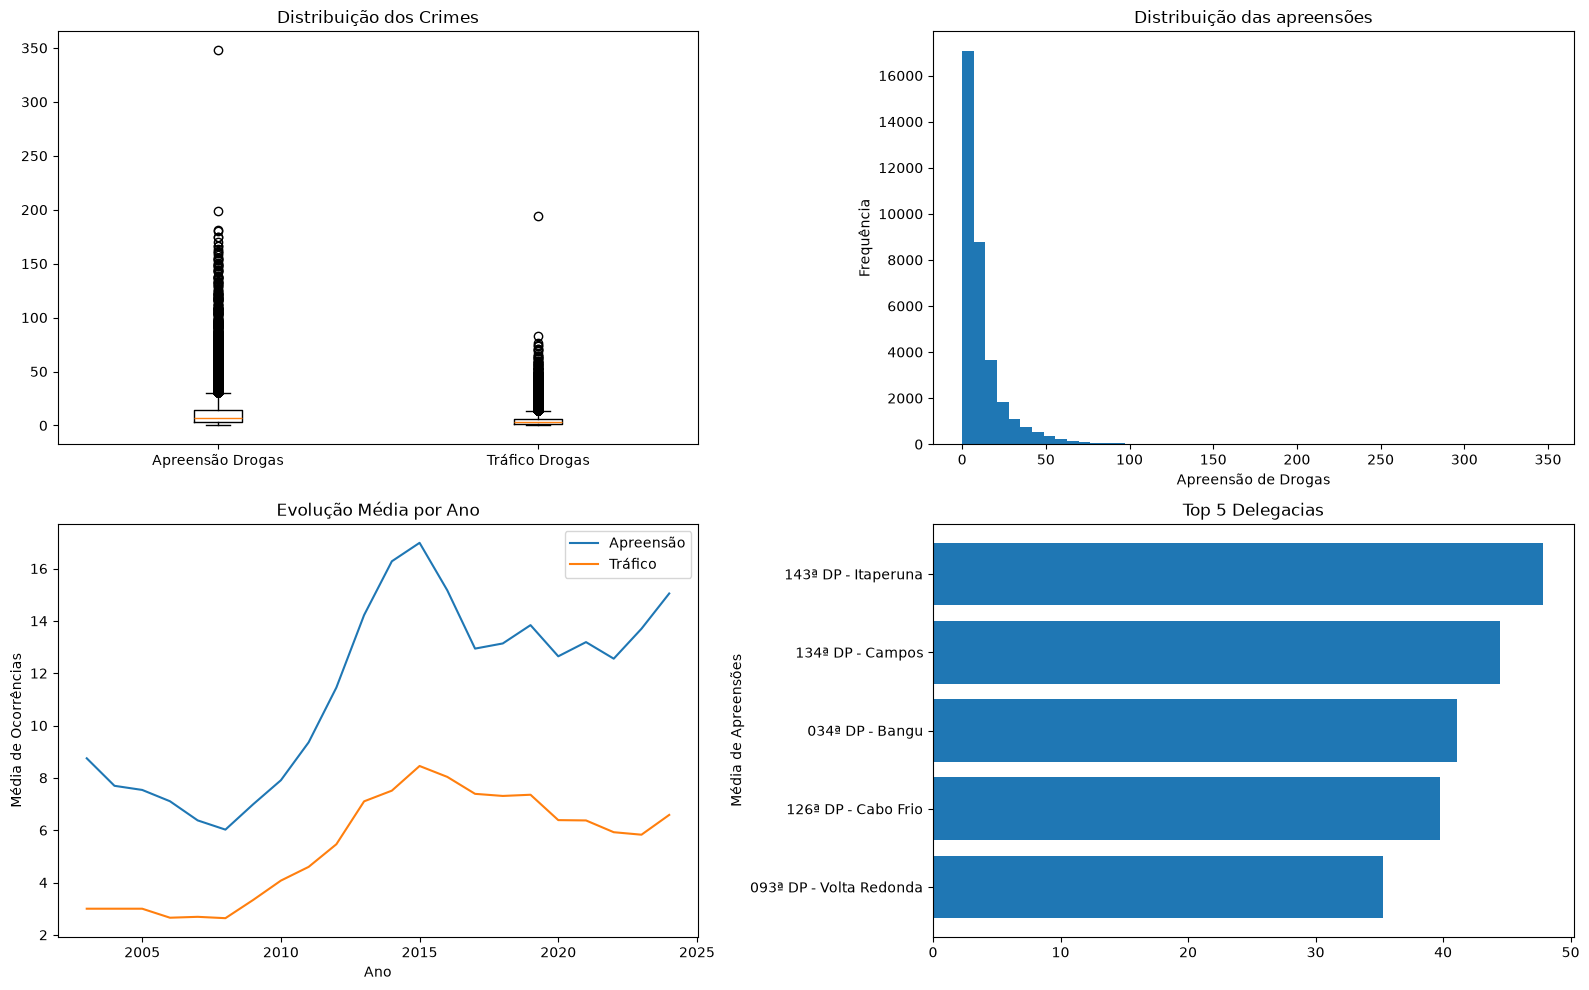

In [ ]:
# VISUALIZAÇÃO DE DADOS

# Boxplot

plt.figure(figsize = (16, 10))
plt.subplot(2, 2, 1)

plt.boxplot([
    crimes_delegacias["apreensao_drogas"],
    crimes_delegacias["trafico_drogas"]
])

plt.xticks(
    [1, 2],
    ["Apreensão Drogas", "Tráfico Drogas"]
)

plt.title("Distribuição dos Crimes")

# Histograma
plt.subplot(2, 2, 2)

plt.hist(
    crimes_delegacias["apreensao_drogas"],
    bins=50
)

plt.title("Distribuição das apreensões")
plt.xlabel("Apreensão de Drogas")
plt.ylabel("Frequência")


serie = (crimes_delegacias.groupby("ano")[["apreensao_drogas","trafico_drogas"]].mean())

# Gráfico de Linha
plt.subplot(2, 2, 3)

plt.plot(
    serie.index,
    serie["apreensao_drogas"],
    label="Apreensão"
)

plt.plot(
    serie.index,
    serie["trafico_drogas"],
    label="Tráfico"
)

plt.title("Evolução Média por Ano")
plt.xlabel("Ano")
plt.ylabel("Média de Ocorrências")
plt.legend()


top5 = (crimes_delegacias.groupby("nome")["apreensao_drogas"].mean().sort_values(ascending=False).head(5))

# Gráfico de Barras
plt.subplot(2, 2, 4)

plt.barh(top5.index, top5.values)
plt.gca().invert_yaxis()

plt.title("Top 5 Delegacias")
plt.ylabel("Média de Apreensões")


plt.tight_layout()
plt.show()

# Interpretação Final

Os resultados da análise descritiva indicam que tanto os registros de apreensão de drogas quanto os de tráfico apresentam distribuições fortemente assimétricas, elevada variabilidade e presença significativa de valores extremos. Isso demonstra que poucas delegacias concentram grande parte das ocorrências, enquanto a maioria apresenta volumes inferiores à média.

A análise regional mostrou que o Interior possui a maior média de apreensões de drogas, enquanto a Grande Niterói lidera a média de ocorrências de tráfico. Essa diferença sugere que os dois indicadores não apresentam necessariamente o mesmo comportamento geográfico, indicando a necessidade de análises específicas para cada tipo de ocorrência.

Entre as delegacias, destacaram-se a **143ª DP - Itaperuna**, **134ª DP - Campos**, **34ª DP - Bangu**, **126ª DP - Cabo Frio** e **93ª DP - Volta Redonda**, que apresentaram as maiores médias de apreensão de drogas durante o período analisado. Esses resultados sugerem que essas unidades merecem acompanhamento mais detalhado para compreender os fatores associados aos elevados registros observados.

De forma geral, a análise evidencia que os dados apresentam comportamento heterogêneo entre regiões e delegacias. Assim, recomenda-se que futuras análises considerem a segmentação geográfica das informações e investiguem individualmente os registros extremos, permitindo uma compreensão mais precisa dos padrões observados e fornecendo subsídios para o planejamento de ações de segurança pública.